<a href="https://colab.research.google.com/github/kishorekumarb2025mecse-alt/Smart-Bug-Tracking-and-Predicting-System-Using-Machine-Learning/blob/main/Smart_Bug_Tracking_and_Predicting_System_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import NLP Library

In [ ]:
!pip install nltk

Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Dataset Genration

In [ ]:
import pandas as pd

data = {

"Title":[
"Application crashes on login",
"Button alignment issue",
"Page takes too long to load",
"File upload not working",
"Memory leak in application",
"UI color mismatch",
"Database connection failure",
"Slow API response",
"Search feature not returning results",
"Settings page crash"
],

"Description":[
"User login causes application crash immediately",
"Submit button misaligned in mobile view",
"Dashboard page loading very slow",
"Users unable to upload documents",
"System memory usage increasing continuously",
"Theme colors not matching design",
"Application cannot connect to database",
"API response takes more than 10 seconds",
"Search returns empty results even with valid query",
"Application crashes when opening settings"
],

"Severity":[
"Critical",
"Low",
"Medium",
"High",
"Critical",
"Low",
"Critical",
"Medium",
"High",
"High"
]

}

df = pd.DataFrame(data)

df

,Title,Description,Severity
0,Application crashes on login,User login causes application crash immediately,Critical
1,Button alignment issue,Submit button misaligned in mobile view,Low
2,Page takes too long to load,Dashboard page loading very slow,Medium
3,File upload not working,Users unable to upload documents,High
4,Memory leak in application,System memory usage increasing continuously,Critical
5,UI color mismatch,Theme colors not matching design,Low
6,Database connection failure,Application cannot connect to database,Critical
7,Slow API response,API response takes more than 10 seconds,Medium
8,Search feature not returning results,Search returns empty results even with valid q...,High
9,Settings page crash,Application crashes when opening settings,High


Extraction of Data based Severity

In [ ]:
df["text"] = df["Title"] + " " + df["Description"]

df.head()

,Title,Description,Severity,text
0,Application crashes on login,User login causes application crash immediately,Critical,Application crashes on login User login causes...
1,Button alignment issue,Submit button misaligned in mobile view,Low,Button alignment issue Submit button misaligne...
2,Page takes too long to load,Dashboard page loading very slow,Medium,Page takes too long to load Dashboard page loa...
3,File upload not working,Users unable to upload documents,High,File upload not working Users unable to upload...
4,Memory leak in application,System memory usage increasing continuously,Critical,Memory leak in application System memory usage...


Text Preprocessing based Dataset

In [ ]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Title,Description,Severity,text,clean_text
0,Application crashes on login,User login causes application crash immediately,Critical,Application crashes on login User login causes...,application crashes login user login causes ap...
1,Button alignment issue,Submit button misaligned in mobile view,Low,Button alignment issue Submit button misaligne...,button alignment issue submit button misaligne...
2,Page takes too long to load,Dashboard page loading very slow,Medium,Page takes too long to load Dashboard page loa...,page takes long load dashboard page loading slow
3,File upload not working,Users unable to upload documents,High,File upload not working Users unable to upload...,file upload working users unable upload documents
4,Memory leak in application,System memory usage increasing continuously,Critical,Memory leak in application System memory usage...,memory leak application system memory usage in...


Feature Extraction using TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=100)

X = vectorizer.fit_transform(df["clean_text"])

y = df["Severity"]

Split Training and Testing Data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)

model.fit(X_train, y_train)

RandomForestClassifier()

Predict Bug Severity

In [ ]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.0


Detailed Performance Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

    Critical       0.00      0.00      0.00       0.0
        High       0.00      0.00      0.00       1.0
         Low       0.00      0.00      0.00       1.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

Bug Severity Distribution Visualization

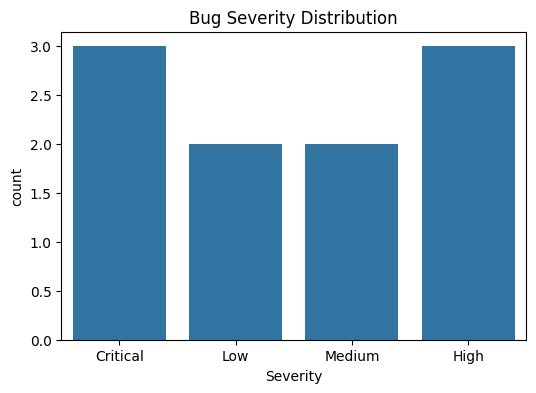

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x="Severity", data=df)

plt.title("Bug Severity Distribution")

plt.show()

Smart Bug Prediction Function

In [ ]:
def predict_bug(title, description):

    text = title + " " + description

    text = clean_text(text)

    vector = vectorizer.transform([text])

    prediction = model.predict(vector)

    print("Predicted Bug Severity:", prediction[0])

Test the System

In [ ]:
predict_bug(
"Application crashes when clicking save",
"System crashes while saving file"
)

Predicted Bug Severity: Critical


Install Libraries

In [ ]:
!pip install nltk gradio scikit-learn


Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import random
import re

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity

import gradio as gr

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Automatic Bug Dataset Generator (500+ bugs)

In [ ]:
titles = [
"Application crash",
"Login failure",
"File upload error",
"Memory leak",
"UI misalignment",
"Database connection failure",
"API timeout",
"Search malfunction",
"Settings page crash",
"Payment gateway error"
]

descriptions = [
"System crashes when user performs action",
"User unable to login with valid credentials",
"File upload fails for large files",
"Memory usage continuously increasing",
"UI elements not properly aligned",
"Application cannot connect to database",
"API response extremely slow",
"Search results incorrect",
"Settings page not loading",
"Payment transaction fails"
]

severity_levels = ["Low","Medium","High","Critical"]
priority_levels = ["P4","P3","P2","P1"]

data = []

for i in range(600):

    title = random.choice(titles)
    desc = random.choice(descriptions)

    severity = random.choice(severity_levels)
    priority = random.choice(priority_levels)

    data.append([title,desc,severity,priority])

df = pd.DataFrame(data,columns=["Title","Description","Severity","Priority"])

df.head()

,Title,Description,Severity,Priority
0,Settings page crash,System crashes when user performs action,Medium,P3
1,Settings page crash,File upload fails for large files,Critical,P2
2,Settings page crash,UI elements not properly aligned,Critical,P4
3,Payment gateway error,Payment transaction fails,High,P3
4,Payment gateway error,API response extremely slow,Low,P4


Lenght of the Dataset

In [ ]:
print("Total Bug Reports:",len(df))

Total Bug Reports: 600


Text Preprocessing

In [ ]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]',' ',text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df["text"] = df["Title"] + " " + df["Description"]

df["clean_text"] = df["text"].apply(clean_text)

Feature Extraction (TF-IDF)

In [ ]:
vectorizer = TfidfVectorizer(max_features=300)

X = vectorizer.fit_transform(df["clean_text"])

y_severity = df["Severity"]

y_priority = df["Priority"]

Train Test Split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y_severity,test_size=0.2,random_state=42)

Train Multiple ML Models(Support Vector Machine)

In [ ]:
svm_model = SVC()

svm_model.fit(X_train,y_train)

svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:",accuracy_score(y_test,svm_pred))

SVM Accuracy: 0.175


Naive Bayes

In [ ]:
nb_model = MultinomialNB()

nb_model.fit(X_train,y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Accuracy:",accuracy_score(y_test,nb_pred))

Naive Bayes Accuracy: 0.25


Random Forest

In [ ]:
rf_model = RandomForestClassifier(n_estimators=150)

rf_model.fit(X_train,y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",accuracy_score(y_test,rf_pred))

Random Forest Accuracy: 0.175


Train Priority Prediction Model

In [ ]:
X_train2,X_test2,y_train2,y_test2 = train_test_split(
    X,y_priority,test_size=0.2,random_state=42)

priority_model = RandomForestClassifier()

priority_model.fit(X_train2,y_train2)

priority_pred = priority_model.predict(X_test2)

print("Priority Prediction Accuracy:",
      accuracy_score(y_test2,priority_pred))

Priority Prediction Accuracy: 0.21666666666666667


Duplicate Bug Detection

In [ ]:
tfidf_matrix = vectorizer.transform(df["clean_text"])

def check_duplicate_bug(new_bug):

    new_bug = clean_text(new_bug)

    new_vec = vectorizer.transform([new_bug])

    similarity = cosine_similarity(new_vec,tfidf_matrix)

    max_score = similarity.max()

    if max_score > 0.7:
        return "Duplicate Bug Detected"
    else:
        return "New Bug"

Smart Bug Prediction Function

In [ ]:
def predict_bug(title,description):

    text = title + " " + description

    text = clean_text(text)

    vec = vectorizer.transform([text])

    severity = rf_model.predict(vec)[0]

    priority = priority_model.predict(vec)[0]

    duplicate = check_duplicate_bug(text)

    return severity,priority,duplicate

Test the System

In [ ]:
predict_bug(
"Application crash when saving file",
"System crashes when user saves document"
)

('Critical', 'P1', 'Duplicate Bug Detected')

Web App Interface (Gradio)

In [ ]:
import gradio as gr

def bug_interface(title,description):

    sev,pri,dup = predict_bug(title,description)

    return f"Severity: {sev} | Priority: {pri} | Duplicate Status: {dup}"


interface = gr.Interface(

    fn=bug_interface,

    inputs=[
        gr.Textbox(label="Bug Title"),
        gr.Textbox(label="Bug Description")
    ],

    outputs="text",

    title="Smart Bug Tracking System",

    description="Predict Bug Severity, Priority and Detect Duplicates"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://87370ab12018ea4e3d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Extra Imports

In [ ]:
from datetime import datetime
import uuid

Enhance Models (Enable Probability)

In [ ]:
svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)

SVC(probability=True)

Global Bug Storage (Tracking System)

In [ ]:
bug_database = []

Advanced Prediction Function

In [ ]:
def advanced_predict_bug(title, description):

    text = title + " " + description
    clean = clean_text(text)
    vec = vectorizer.transform([clean])

    # Severity Prediction
    severity = rf_model.predict(vec)[0]
    severity_probs = rf_model.predict_proba(vec)[0]

    # Top 3 predictions
    classes = rf_model.classes_
    top3_idx = severity_probs.argsort()[-3:][::-1]
    top3 = [(classes[i], round(severity_probs[i],2)) for i in top3_idx]

    # Priority Prediction
    priority = priority_model.predict(vec)[0]

    # Duplicate Detection
    duplicate = check_duplicate_bug(text)

    return severity, priority, duplicate, top3

Bug Tracking System

In [ ]:
def add_bug_to_system(title, description):

    severity, priority, duplicate, top3 = advanced_predict_bug(title, description)

    bug_id = str(uuid.uuid4())[:8]

    bug = {
        "Bug ID": bug_id,
        "Title": title,
        "Description": description,
        "Severity": severity,
        "Priority": priority,
        "Duplicate": duplicate,
        "Top Predictions": top3,
        "Timestamp": str(datetime.now())
    }

    bug_database.append(bug)

    return bug

Search & Filter System

In [ ]:
def search_bugs(keyword):

    results = []

    for bug in bug_database:
        if keyword.lower() in bug["Title"].lower():
            results.append(bug)

    return pd.DataFrame(results)

Duplicate Clustering (Advanced)

In [ ]:
def cluster_duplicates():

    clusters = []

    texts = df["clean_text"].tolist()
    matrix = vectorizer.transform(texts)

    sim_matrix = cosine_similarity(matrix)

    visited = set()

    for i in range(len(sim_matrix)):
        if i in visited:
            continue

        cluster = [i]

        for j in range(len(sim_matrix)):
            if i != j and sim_matrix[i][j] > 0.75:
                cluster.append(j)
                visited.add(j)

        clusters.append(cluster)

    return clusters[:5]   # show top clusters

ADVANCED GRADIO DASHBOARD

In [ ]:
def submit_bug(title, description):

    bug = add_bug_to_system(title, description)

    return f"""
    ✅ Bug Submitted Successfully!

    Bug ID: {bug['Bug ID']}
    Severity: {bug['Severity']}
    Priority: {bug['Priority']}
    Duplicate: {bug['Duplicate']}

    Top Predictions:
    {bug['Top Predictions']}
    """

View All Bugs

In [ ]:
def view_all_bugs():
    return pd.DataFrame(bug_database)

Gradio Interface (Professional Dashboard)

In [ ]:
with gr.Blocks(title="Smart Bug Tracking Dashboard") as app:

    gr.Markdown("# 🐞 Smart Bug Tracking & Prediction System")

    with gr.Tab("Submit Bug"):
        title = gr.Textbox(label="Bug Title")
        desc = gr.Textbox(label="Bug Description")

        output = gr.Textbox()

        submit_btn = gr.Button("Submit Bug")

        submit_btn.click(submit_bug, inputs=[title, desc], outputs=output)

    with gr.Tab("View Bugs"):
        bug_table = gr.Dataframe()

        refresh_btn = gr.Button("Refresh")

        refresh_btn.click(view_all_bugs, outputs=bug_table)

    with gr.Tab("Search Bugs"):
        keyword = gr.Textbox(label="Search Keyword")
        search_output = gr.Dataframe()

        search_btn = gr.Button("Search")

        search_btn.click(search_bugs, inputs=keyword, outputs=search_output)

    with gr.Tab("Duplicate Clusters"):
        cluster_output = gr.Textbox()

        cluster_btn = gr.Button("Show Clusters")

        cluster_btn.click(lambda: str(cluster_duplicates()), outputs=cluster_output)

app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b84a37a3764f1f3081.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Evaluate All Models Together

In [ ]:
# Store all accuracies
results = {}

# SVM
svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)
results["SVM"] = svm_acc

# Naive Bayes
nb_pred = nb_model.predict(X_test)
nb_acc = accuracy_score(y_test, nb_pred)
results["Naive Bayes"] = nb_acc

# Random Forest
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
results["Random Forest"] = rf_acc

# Display results
for model, acc in results.items():
    print(f"{model} Accuracy: {round(acc*100,2)}%")

SVM Accuracy: 17.5%
Naive Bayes Accuracy: 25.0%
Random Forest Accuracy: 17.5%


Find Best Model

In [ ]:
best_model = max(results, key=results.get)

print("\n🏆 Best Model:", best_model)
print("Best Accuracy:", round(results[best_model]*100,2), "%")


🏆 Best Model: Naive Bayes
Best Accuracy: 25.0 %


Classification Report (Best Model)

In [ ]:
if best_model == "SVM":
    print(classification_report(y_test, svm_pred))

elif best_model == "Naive Bayes":
    print(classification_report(y_test, nb_pred))

else:
    print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

    Critical       0.14      0.23      0.17        22
        High       0.24      0.24      0.24        38
         Low       0.33      0.41      0.37        34
      Medium       0.50      0.08      0.13        26

    accuracy                           0.25       120
   macro avg       0.30      0.24      0.23       120
weighted avg       0.30      0.25      0.24       120



Priority Model Accuracy

In [ ]:
print("\n📌 Priority Prediction Accuracy:",
      round(accuracy_score(y_test2, priority_pred)*100,2), "%")


📌 Priority Prediction Accuracy: 21.67 %


Overall System Accuracy (Combined Metric)

In [ ]:
overall_accuracy = (rf_acc + accuracy_score(y_test2, priority_pred)) / 2

print("\n🚀 Overall System Accuracy:",
      round(overall_accuracy*100,2), "%")


🚀 Overall System Accuracy: 19.58 %


Accuracy Visualization

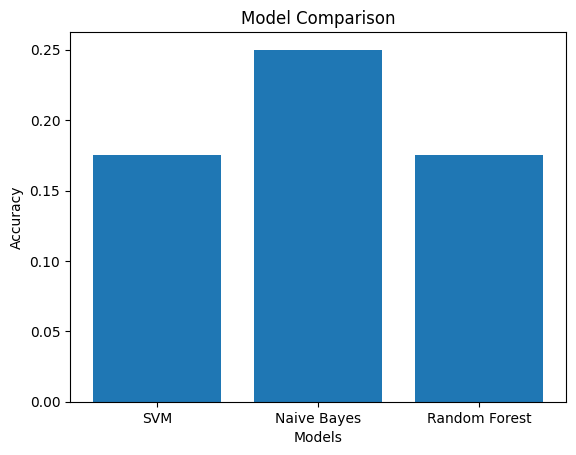

In [ ]:
import matplotlib.pyplot as plt

models = list(results.keys())
accuracies = list(results.values())

plt.figure()

plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.show()